<a href="https://colab.research.google.com/github/mbrow210/MAT-422/blob/main/1_3_QR_Regression_Least_Squares_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.3: QR Decomposition, Least Squares, and Linear Regression

**Topics**: QR decomposition, least-squares problems, linear regression

Linear regression makes statistical properties easier to determine since the model depends linearly on unknown parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

### **1.3.1 QR Decomposition**

QR decomposition factors a matrix A into A=QR. The columns of Q are orthonormal, meaning their dot products form the identity matrix, and R is upper triangular. This is useful because orthonormal columns make projections and least-squares calculations cleaner.

QR decomposition procedure uses the Gram-Schmidt algorithm to obtain an orthonormal basis. This must be derived from a linearly independent set of vectors in a span.

Given a span of linearly independent vectors, A, the result of Gram-Schmidt procedure on A would result in A=QR, where R contains coefficients of the linear combinations from Q that produces A.

In [2]:
def print_qr_decomp(Q,R):
  print("\nQ =\n",Q)
  print("\nR =\n",R)
  print("\nQ.T @ Q =\n",Q.T @ Q)
  print("\nQ @ R =\n",Q @ R)
  print("Q has orthonormal columns?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
  print("Q @ R reconstructs A?", np.allclose(Q @ R, A))

In [3]:
def get_square_matrix(d):
  '''Returns a randomly generated square matrix'''
  return np.random.randint(0,20,[d,d])

In [4]:
def gramschmidt(A):
  # step 1: normalize
  # step 2: project, compute residual, normalize residual
  # step 3: repeat step 2 until all columns have been processed
  m,n = A.shape
  Q = np.zeros((m,n)) # e
  R = np.zeros((m,n)) # a*e

  A_T = A.T

  # iterate over all columns in matrix
  # to avoid errors, we iterate using an index j
  for j in range(n):
    v = A_T[j].copy() # initial vector
    # compute residual(s) for each previous vectors
    for i in range(j):
      R[i,j] = np.dot(Q[:,i],A[:,j])
      v = v- R[i,j] * Q[:,i]
    # normalize vector v
    R[j,j] = np.linalg.norm(v)

    if R[j,j] > 1e-10: # ensures we don't divide by 0
      Q[:,j] = v / R[j,j]
    else:
      Q[:,j] = v
  return Q,R


In [5]:
A = get_square_matrix(3)
Q,R = gramschmidt(A)
Q_np,R_np = np.linalg.qr(A)

print("Randomly generated square matrix: \n",A)
print("\n\nQR Decomp with manual Gram-Schmidt function:")
print_qr_decomp(Q,R)
print("\n\nQR Decomp with built-in Numpy function:")
print_qr_decomp(Q_np,R_np)

Randomly generated square matrix: 
 [[ 0  1 13]
 [19 15 19]
 [ 5  1  8]]


QR Decomp with manual Gram-Schmidt function:

Q =
 [[ 0.      0.3311  0.9436]
 [ 0.9671  0.2401 -0.0843]
 [ 0.2545 -0.9125  0.3202]]

R =
 [[19.6469 14.7606 20.4104]
 [ 0.      3.0207  1.5661]
 [ 0.      0.     13.2274]]

Q.T @ Q =
 [[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Q @ R =
 [[ 0.  1. 13.]
 [19. 15. 19.]
 [ 5.  1.  8.]]
Q has orthonormal columns? True
Q @ R reconstructs A? True


QR Decomp with built-in Numpy function:

Q =
 [[ 0.      0.3311  0.9436]
 [-0.9671  0.2401 -0.0843]
 [-0.2545 -0.9125  0.3202]]

R =
 [[-19.6469 -14.7606 -20.4104]
 [  0.       3.0207   1.5661]
 [  0.       0.      13.2274]]

Q.T @ Q =
 [[ 1. -0. -0.]
 [-0.  1. -0.]
 [-0. -0.  1.]]

Q @ R =
 [[ 0.  1. 13.]
 [19. 15. 19.]
 [ 5.  1.  8.]]
Q has orthonormal columns? True
Q @ R reconstructs A? True


We see that the transpose of a matrix with orthonormal columns is the same as the matrix's left inverse. Visible with Q.T @ Q, this means that this can be easily verified by checking that the result of the above calculation (Q^T Q) equals the identity matrix.

Orthonormal columns make computations stable and interpretable because matrices with orthonormal columns can by broken down with QR decomposition, which provides the upper triangular matrix, R. An upper triangular matrix is the simplest and most straightforwad matrix to solve since it can be interpreted with back substitution.

### **1.3.2 Least-Squares Problems**

A least-squares problem solves an overdetermined system A x approximately equals b. There may be no exact solution, so we choose x that minimizes the residual norm ||b - Ax||. QR decomposition gives a stable way to solve this problem.

Use an overdetermined linear system A x approximately equals b. Show that the least-squares solution minimizes the residual norm when an exact solution usually does not exist.

In [7]:

A = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4],
], dtype=float)

b = np.array([1.2, 1.9, 3.2, 3.9], dtype=float)

# solution computed using np.linalg.lstsq
x_lstsq, residual_sum, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

# residual computed with b-A@x_hat
residual = b - A @ x_lstsq

# norm of residual
norm = np.linalg.norm(residual)

print("Least-squares solution from np.linalg.lstsq:", x_lstsq)
print("Residual vector b - A @ x =", residual)
print("Residual norm =", norm)
print("Rank of A =", rank)
print("Singular values =", singular_values)
print("Normal-equation check A.T @ residual =", A.T @ residual)

Least-squares solution from np.linalg.lstsq: [0.2  0.94]
Residual vector b - A @ x = [ 0.06 -0.18  0.18 -0.06]
Residual norm = 0.268328157299975
Rank of A = 2
Singular values = [5.7794 0.7738]
Normal-equation check A.T @ residual = [0. 0.]


Compare with solving through QR: Rx = Q.T*b for full-rank A

Optionally check the normal-equation condition A.t @ residual is close to zero.

When trying to solve Ax=b to approximate b, the solution is often inconsistent.

We assume that A has linearly independent columns.

If A is a square matrix, we can use its inverse to solve it, but in an overdetermined system where n columns are greater than m rows, the matrix inverse can't be used.

It is possible to circumvent this problem by using it as a least-squares problem.

min_(x in R^m)||Ax-b||

To compute this least-squares problem, we use orthogonal projection of on matrix A's column space in terms of b, meaning we project b onto A as b_hat.

We know b_hat is in the column space of A, therefore its consistent and we know an x_hat exists where A*x_hat=b_hat.

### **1.3.3 Linear Regression**

#### **Overview**

Linear regression is a tool that can be used to model relationships between a dependent variable and an independent variable(s). It works by fitting a linear equation over the given data points.

This could be used to show trends across a wide set of data points, like temperature trends over time, and is often used in machine learning.


#### **Types and definitions**

There are two types of linear regression, multiple linear regression and simple linear regression. For this assignment the focus is simple linear regression which uses only one independent variable.

When using linear regression, the goal is to find the best 'fit' line for the points of data. The variable Y can be referred to as the dependent variable, and X is the independent variable. Beta_0 is the intercept, and beta_1 is the slope.

The equation for the best fit line is represented by the equation:

`y=mx+b`

m=slope

b=intercept

y=dependent variable

x=independent variable

#### **Room for Error**

The best-fit line should be as close to the actual data points as posible, so the residuals (difference between fitted-line and actual data points) should be minimized.

To calculate the residual, subtract the predicted value from the fitted line at a given x value from the actual value at the given x value.

Least squares, the method used in the previous example, sums the square of the residuals.

#### **Root Mean Square Error (RMSE)**

The RMSE is the square root of the mean of the errors squared and is used in measuring/determining if the fit of a regression line is good.

$RMSE= \sqrt{\frac{1}{n}\Sigma^{n}_{i=1}(y_i-\hat{y}_i)^2}$

In [8]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_data = np.array([1.1, 2.0, 2.9, 4.2, 5.1, 5.9], dtype=float)

X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_pred = X @ beta
regression_residuals = y_data - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Design matrix X =")
print(X)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y =", y_pred)
print("residuals =", regression_residuals)
print("RMSE =", rmse)

Design matrix X =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
beta_0 intercept = 1.061904761904761
beta_1 slope = 0.988571428571429
predicted y = [1.0619 2.0505 3.039  4.0276 5.0162 6.0048]
residuals = [ 0.0381 -0.0505 -0.139   0.1724  0.0838 -0.1048]
RMSE = 0.10881759895012307


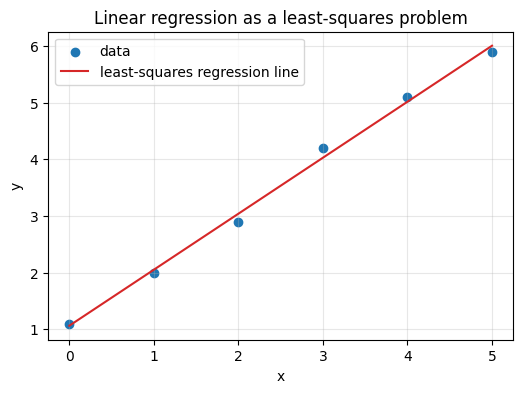

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y_data, color="tab:blue", label="data")
plt.plot(x, y_pred, color="tab:red", label="least-squares regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression as a least-squares problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
# DATA RETRIEVED FROM KAGGLE AT: https://www.kaggle.com/datasets/vipullrathod/fish-market
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Set the path to the file you'd like to load
file_path = "Fish.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vipullrathod/fish-market",
  file_path
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_2411/1815970058.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fish-market' dataset.
First 5 records:   Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340


In [27]:
x = df['Weight'].values
y_data = df['Height'].values

X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_pred = X @ beta
regression_residuals = y_data - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Size of dataset: ", len(x))

print("\nDesign matrix X (first 5 data points)=")
print(X[:5])
print("\nbeta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("\npredicted y (first 5 data points)=", y_pred[:5])
print("residuals (first 5 data points)=", regression_residuals[:5])
print("RMSE =", rmse)

Size of dataset:  159

Design matrix X (first 5 data points)=
[[  1. 242.]
 [  1. 290.]
 [  1. 340.]
 [  1. 363.]
 [  1. 430.]]

beta_0 intercept = 5.516365983750856
beta_1 slope = 0.008672856220501405

predicted y (first 5 data points)= [7.6152 8.0315 8.4651 8.6646 9.2457]
residuals (first 5 data points)= [3.9048 4.4485 3.9127 4.0654 3.1983]
RMSE = 2.945764239689587


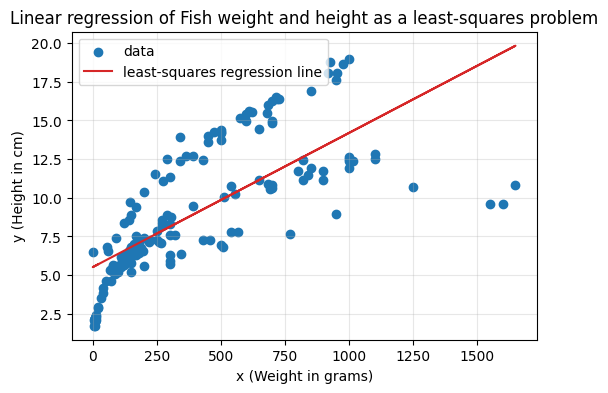

In [28]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y_data, color="tab:blue", label="data")
plt.plot(x, y_pred, color="tab:red", label="least-squares regression line")
plt.xlabel("x (Weight in grams)")
plt.ylabel("y (Height in cm)")
plt.title("Linear regression of Fish weight and height as a least-squares problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

From this, we can see that data suggests some correlation between fish weight having an impact on the fish's height.